In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df=pd.read_csv('Student_Performance.csv')

In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder()

# Fit and transform
encoded_array = encoder.fit_transform(df[['Extracurricular Activities']]).toarray()

# Create DataFrame with correct column names
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['Extracurricular Activities'])
)

# Reset index
df = df.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

# Drop original column
df.drop('Extracurricular Activities', axis=1, inplace=True)

# Concatenate
df = pd.concat([df, encoded_df], axis=1)

df.head()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_No,Extracurricular Activities_Yes
0,7,99,9,1,91.0,0.0,1.0
1,4,82,4,2,65.0,1.0,0.0
2,8,51,7,2,45.0,0.0,1.0
3,5,52,5,2,36.0,0.0,1.0
4,7,75,8,5,66.0,1.0,0.0


In [6]:
df.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_No,Extracurricular Activities_Yes
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730,-0.003873,0.003873
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189,-0.008369,0.008369
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106,0.023284,-0.023284
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268,-0.013103,0.013103
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000,-0.024525,0.024525
Extracurricular Activities_No,-0.003873,-0.008369,0.023284,-0.013103,-0.024525,1.000000,-1.000000
Extracurricular Activities_Yes,0.003873,0.008369,-0.023284,0.013103,0.024525,-1.000000,1.000000


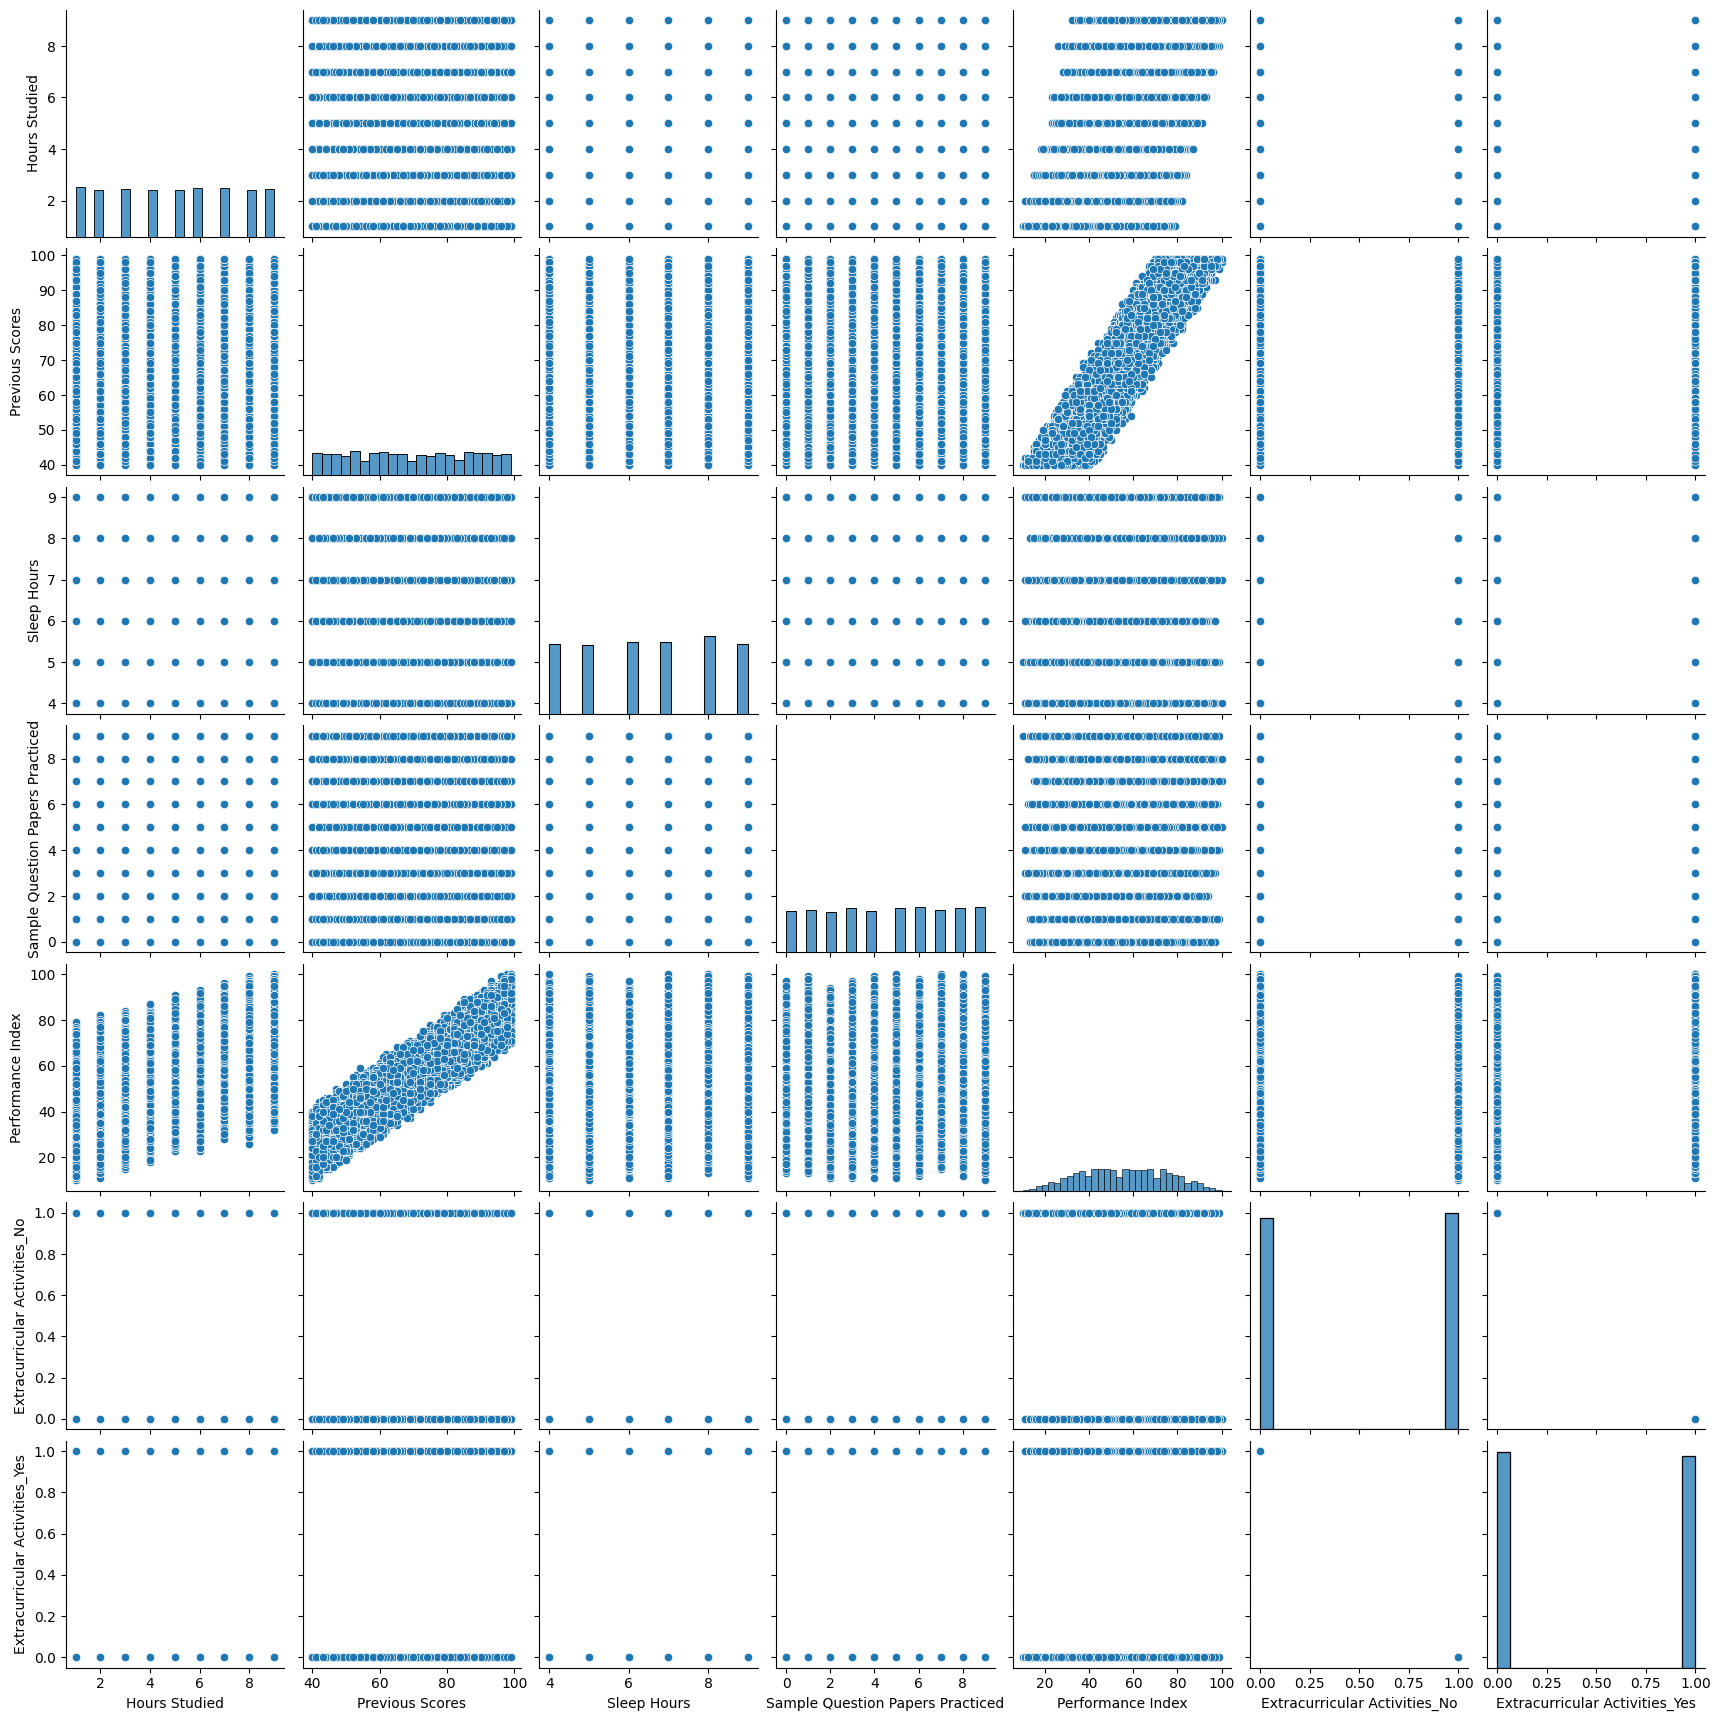

In [7]:
##Lets visualize the data
import seaborn as sns
sns.pairplot(df)

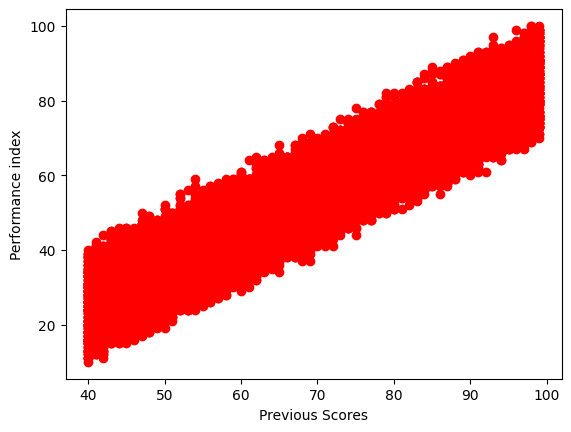

In [8]:
##Lets visualize it closelly
plt.scatter(x=df['Previous Scores'],y=df['Performance Index'],color='r')
plt.xlabel("Previous Scores")
plt.ylabel("Performance index")
plt.show()

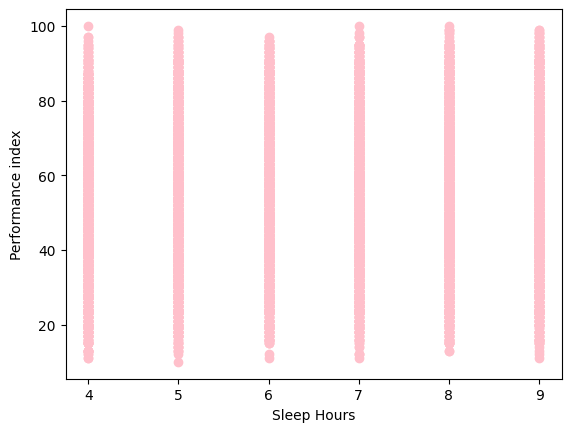

In [9]:
##Lets visualize it closelly
plt.scatter(x=df['Sleep Hours'],y=df['Performance Index'],color='pink')
plt.xlabel("Sleep Hours")
plt.ylabel("Performance index")
plt.show()

In [10]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
Extracurricular Activities_No       0
Extracurricular Activities_Yes      0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Sleep Hours                       10000 non-null  int64  
 3   Sample Question Papers Practiced  10000 non-null  int64  
 4   Performance Index                 10000 non-null  float64
 5   Extracurricular Activities_No     10000 non-null  float64
 6   Extracurricular Activities_Yes    10000 non-null  float64
dtypes: float64(3), int64(4)
memory usage: 547.0 KB


In [12]:
df.head()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_No,Extracurricular Activities_Yes
0,7,99,9,1,91.0,0.0,1.0
1,4,82,4,2,65.0,1.0,0.0
2,8,51,7,2,45.0,0.0,1.0
3,5,52,5,2,36.0,0.0,1.0
4,7,75,8,5,66.0,1.0,0.0


In [13]:
## Getting the independent and dependent feature
X=df[['Hours Studied','Previous Scores','Sleep Hours','Sample Question Papers Practiced','Extracurricular Activities_No','Extracurricular Activities_Yes']]
y=df['Performance Index']

In [14]:
##Getting train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

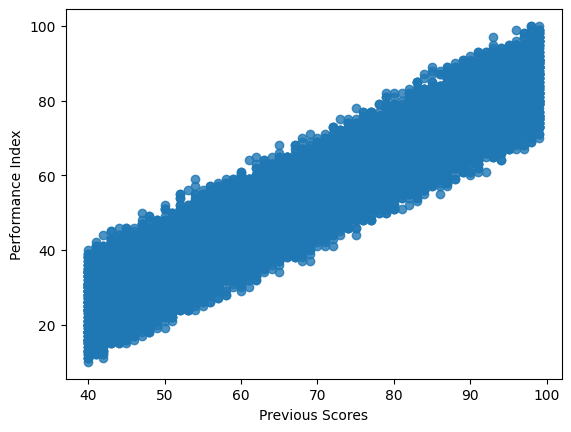

In [15]:
sns.regplot(x=df['Previous Scores'],y=df['Performance Index'])

<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

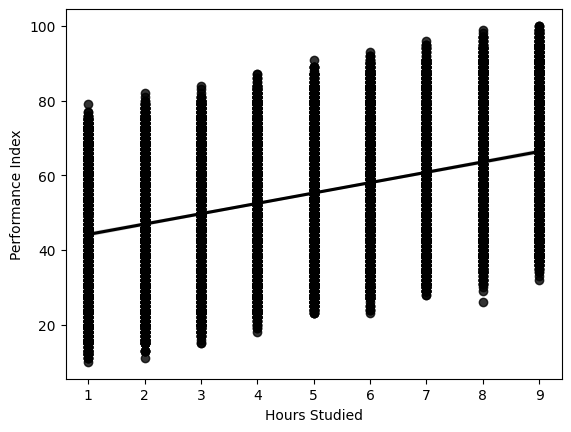

In [16]:
sns.regplot(x=df['Hours Studied'],y=df['Performance Index'],color='Black')

In [17]:
##Lets Standardize the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [18]:
X_train

array([[-0.37921729,  1.69543433, -0.31944271, -1.26226064, -1.01962103,
         1.01962103],
       [ 0.39110222,  1.17637842,  1.44869036, -0.56482402, -1.01962103,
         1.01962103],
       [ 1.16142173, -0.72682657, -0.31944271, -1.26226064,  0.98075655,
        -0.98075655],
       ...,
       [ 1.54658149, -1.24588248,  0.26993498,  0.4813309 ,  0.98075655,
        -0.98075655],
       [-1.53469656, -1.30355536,  1.44869036, -1.61097894,  0.98075655,
        -0.98075655],
       [-1.1495368 , -1.36122824, -0.31944271,  0.4813309 ,  0.98075655,
        -0.98075655]], shape=(7000, 6))

In [19]:
## Regression 
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
print(regression.coef_)
print(regression.intercept_)

[ 7.42276987 17.60827303  0.8138699   0.54598268 -0.14540076  0.14540076]
55.39971428571428


In [21]:
y_pred=regression.predict(X_test)

In [22]:
## Creating sparce matrix
import math
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=math.sqrt(mse)
print(mse)
print(mae)
print(rmse)

4.066563824092691
1.609043756404524
2.0165722957763483


In [ ]:
##Calculating r2 score
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.9890110607021136


In [24]:
## Dispalying adjusted r2
adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(adjusted_score)

0.988989031421864


In [25]:
## OLS linear reggression
import  statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)
print(model.summary())

[ -3.66640591 -26.57419973  -2.15556486 ... -16.02523537  17.48344119
 -18.2370962 ]
                                 OLS Regression Results                                
Dep. Variable:      Performance Index   R-squared (uncentered):                   0.130
Model:                            OLS   Adj. R-squared (uncentered):              0.129
Method:                 Least Squares   F-statistic:                              208.8
Date:                Thu, 19 Feb 2026   Prob (F-statistic):                   3.67e-208
Time:                        14:35:33   Log-Likelihood:                         -37945.
No. Observations:                7000   AIC:                                  7.590e+04
Df Residuals:                    6995   BIC:                                  7.593e+04
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err   